### Xây dựng và huấn luyện mô hình GRU

#### Chuẩn bị dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [3]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [4]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [5]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [7]:
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [8]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [9]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

#### Xây dựng mô hình

In [10]:
# Khai báo thư viện
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [11]:
print("Train shape:", X_train_seq.shape)
print("Test shape :", X_test_seq.shape)

Train shape: (8513, 30, 3)
Test shape : (1802, 30, 3)


In [12]:
# Xây dựng mô hình GRU
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = Sequential([
    Input(shape=input_shape),
    GRU(50),
    Dense(1)
])

In [13]:
# Biên dịch mô hình
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           8,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,301 (32.43 KB)

 Trainable params: 8,301 (32.43 KB)

 Non-trainable params: 0 (0.00 B)

#### Huấn luyện mô hình

In [15]:
# # Thiết lập callbacks
# # checkpoint = ModelCheckpoint('best_gru_model.h5', save_best_only=True, monitor='val_loss', mode='min')
# checkpoint = ModelCheckpoint(
#     "best_model_gru.keras",
#     monitor="val_loss",
#     save_best_only=True,
#     mode="min"
# )
# # early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=10,     # Nếu 10 epoch không cải thiện thì dừng
#     restore_best_weights=True,
#     verbose=1
# )

In [16]:
# Huấn luyện mô hình với epochs=50, batch_size=32 
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    # callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0266 - mae: 0.1274 - val_loss: 0.0131 - val_mae: 0.0910
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0115 - mae: 0.0838 - val_loss: 0.0082 - val_mae: 0.0721
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0100 - mae: 0.0781 - val_loss: 0.0104 - val_mae: 0.0812
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0095 - mae: 0.0764 - val_loss: 0.0088 - val_mae: 0.0739
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0092 - mae: 0.0747 - val_loss: 0.0067 - val_mae: 0.0645
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0091 - mae: 0.0740 - val_loss: 0.0095 - val_mae: 0.0763
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0092 - mae: 0.0745 - val_loss: 0.0130 - val_mae: 0.0946
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0089 - mae: 0.0733 - val_loss: 0.0064 - val_mae: 0.0624
Epoch 9/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - lo

In [17]:
print("Best val_loss:", min(history.history['val_loss']))

Best val_loss: 0.006009827833622694


In [18]:
# Dự đoán trên tập TEST
y_pred_scaled = model.predict(X_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


In [19]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_seq)

# Đảo ngược chuẩn hóa để có giá trị thực tế
# y_test_rescaled = np.zeros((len(y_test), scaled_data.shape[1]))
# y_pred_rescaled = np.zeros((len(y_pred), scaled_data.shape[1]))

# y_test_rescaled[:, 1] = y_test
# y_pred_rescaled[:, 1] = y_pred.flatten()

# y_test_original = scaler.inverse_transform(y_test_rescaled)[:, 1]
# y_pred_original = scaler.inverse_transform(y_pred_rescaled)[:, 1]

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 1.6416782100352008
RMSE: 1.281279910884113
MAE : 1.0339741076216447
R2  : 0.38503362711157807


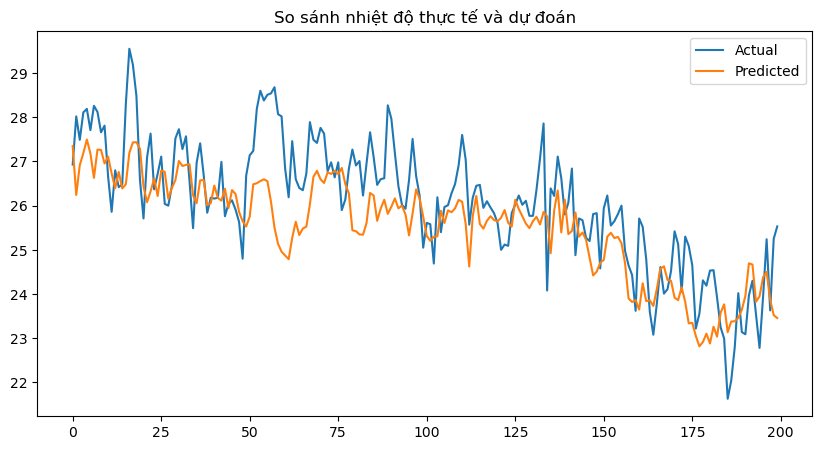

In [21]:
 # Vẽ biểu đồ so sánh Thực tế vs Dự đoán
plt.figure(figsize=(10,5))
plt.plot(y_test_original[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("So sánh nhiệt độ thực tế và dự đoán")
plt.show()

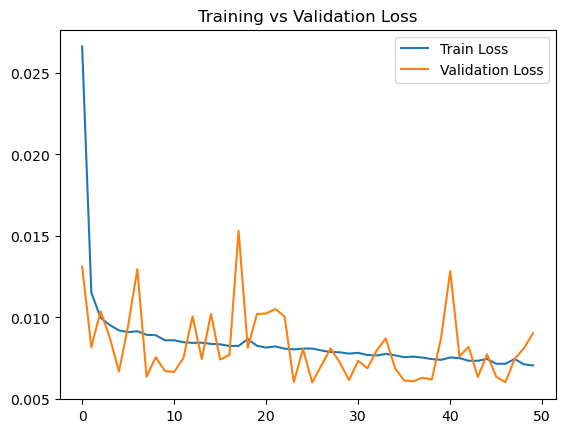

In [22]:
# Vẽ biểu đồ Loss trong quá trình train
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [23]:
print("===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====")
print(f"Sai số bình phương trung bình (MSE): {mse:.4f}")
print(f"Căn bậc hai sai số (RMSE): {rmse:.4f} °C")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:.4f} °C")
print(f"Hệ số xác định (R²): {r2:.4f}")

===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====
Sai số bình phương trung bình (MSE): 1.6417
Căn bậc hai sai số (RMSE): 1.2813 °C
Sai số tuyệt đối trung bình (MAE): 1.0340 °C
Hệ số xác định (R²): 0.3850


In [24]:
comparison_df = pd.DataFrame({
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df["Sai số"] = comparison_df["Nhiệt độ thực tế (°C)"] - comparison_df["Nhiệt độ dự đoán (°C)"]
comparison_df["Sai số tuyệt đối"] = comparison_df["Sai số"].abs()

print("===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====")
display(comparison_df.round(2).head(10))

===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C),Sai số,Sai số tuyệt đối
0,26.93,27.350000,-0.42,0.42
1,28.02,26.240000,1.78,1.78
2,27.49,26.920000,0.57,0.57
3,28.11,27.190001,0.92,0.92
4,28.19,27.500000,0.69,0.69
5,27.71,27.180000,0.53,0.53
6,28.26,26.629999,1.63,1.63
7,28.12,27.270000,0.85,0.85
8,27.66,27.260000,0.40,0.40
9,27.81,26.950001,0.86,0.86


In [25]:
# Lấy index tương ứng với tập test gốc
test_index = df.index[-len(y_test_seq):]

comparison_df = pd.DataFrame({
    "Ngày": test_index,
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df.set_index("Ngày", inplace=True)
comparison_df.head(20)

print("===== SO SÁNH THEO TỪNG NGÀY =====")
display(comparison_df.round(2).head(20))

===== SO SÁNH THEO TỪNG NGÀY =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C)
Ngày,,
2013-06-26,26.93,27.350000
2013-06-27,28.02,26.240000
2013-06-28,27.49,26.920000
2013-06-29,28.11,27.190001
2013-06-30,28.19,27.500000
2013-07-01,27.71,27.180000
2013-07-02,28.26,26.629999
2013-07-03,28.12,27.270000
2013-07-04,27.66,27.260000


In [26]:
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
print(f"Sai số phần trăm trung bình (MAPE): {mape:.2f}%")

Sai số phần trăm trung bình (MAPE): 3.88%


In [27]:
model.save("model_gru.keras")